In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

with open(Path("/Users/gtzanettis/Documents/Projects/agent-task-distribution/results/analytical/topology_equilibriums.json")) as f:
    data = json.load(f)

ALGOS = ["per_node", "all_in_one", "all_separate", "per_workflow", "tig_greedy_modularity"]
ALGO_LABELS = {
    "per_node":              "per_node",
    "all_in_one":            "all_in_one",
    "all_separate":          "all_separate",
    "per_workflow":          "per_workflow",
    "tig_greedy_modularity": "TIG greedy_modularity (custom)",
}
ALGO_COLORS = {
    "per_node":              "#4C72B0",
    "all_in_one":            "#55A868",
    "all_separate":          "#DD8452",
    "per_workflow":          "#C44E52",
    "tig_greedy_modularity": "#8172B2",
}
ALGO_MARKERS = {
    "per_node":              "o",
    "all_in_one":            "s",
    "all_separate":          "^",
    "per_workflow":          "D",
    "tig_greedy_modularity": "*",
}

METRICS = ["worst_U1", "avg_U1", "worst_U2", "avg_U2", "PoA", "max_agent_as"]
METRIC_LABELS = {
    "worst_U1":     "Worst U1",
    "avg_U1":       "Avg U1",
    "worst_U2":     "Worst U2",
    "avg_U2":       "Avg U2",
    "PoA":          "PoA",
    "max_agent_as": "Max-Agent Action Space",
}


def _as_size(M):
    if M <= 2: return 5
    if M == 3: return 3
    return 2

def max_agent_action_space(assignment, M):
    n = _as_size(M)
    return max(n ** len(sids) for sids in assignment.values())


def compute_topo_metrics(mapping, M, N):
    node_counts = Counter(mapping.values())
    counts = [node_counts.get(f"n{i}", 0) for i in range(N)]
    n_colocated = sum(
        1 for w in range(M) if mapping[f"w{w}_s0"] == mapping[f"w{w}_s1"]
    )
    cross_pairs = [
        (w1, s1, w2, s2)
        for w1 in range(M) for w2 in range(w1 + 1, M)
        for s1 in range(2) for s2 in range(2)
    ]
    cross_shared = sum(
        1 for w1, s1, w2, s2 in cross_pairs
        if mapping[f"w{w1}_s{s1}"] == mapping[f"w{w2}_s{s2}"]
    )
    return {
        "t_pct_colocated":   n_colocated / M,
        "t_frac_nodes_used": sum(1 for c in counts if c > 0) / N,
        "t_max_node_load":   max(counts),
        "t_load_std":        float(np.std(counts)),
        "t_cross_wf_coloc":  cross_shared / len(cross_pairs) if cross_pairs else 0.0,
    }


# Flatten: one record per (topology × algo)
records = []
for key, topologies in data.items():
    M_val = int(key.split("_")[0][1:])
    N_val = int(key.split("_")[1][1:])
    for t in topologies:
        topo_m = compute_topo_metrics(t["mapping"], M_val, N_val)
        for algo in ALGOS:
            if algo not in t:
                continue
            m = t[algo]
            perf = {k: m[k] for k in ["worst_U1", "avg_U1", "worst_U2", "avg_U2", "PoA"]}
            perf["max_agent_as"] = max_agent_action_space(m["assignment"], M_val)
            records.append({
                "M": M_val, "N": N_val, "algo": algo,
                **perf,
                **topo_m,
            })


def grouped_means(records, group_key):
    buckets = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for r in records:
        g, a = r[group_key], r["algo"]
        for m in METRICS:
            if r[m] is not None:
                buckets[g][a][m].append(r[m])
    return {
        g: {a: {m: np.mean(v) for m, v in md.items()} for a, md in ad.items()}
        for g, ad in sorted(buckets.items())
    }

def grouped_means_by_mn(records):
    buckets = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for r in records:
        g = (r["M"], r["N"])
        a = r["algo"]
        for m in METRICS:
            if r[m] is not None:
                buckets[g][a][m].append(r[m])
    return {
        g: {a: {m: np.mean(v) for m, v in md.items()} for a, md in ad.items()}
        for g, ad in sorted(buckets.items())
    }

by_N  = grouped_means(records, "N")
by_M  = grouped_means(records, "M")
by_MN = grouped_means_by_mn(records)

# ── Grand averages across all (M, N, topology) combinations ──────────────────
grand: dict[str, dict[str, float]] = defaultdict(dict)
for algo in ALGOS:
    for metric in METRICS:
        vals = [r[metric] for r in records if r["algo"] == algo and r[metric] is not None]
        grand[algo][metric] = np.mean(vals) if vals else float("nan")

col_w  = max(len(METRIC_LABELS[m]) for m in METRICS) + 2
row_w  = max(len(a) for a in ALGOS) + 2
header = f"{'Algorithm':<{row_w}}" + "".join(f"{METRIC_LABELS[m]:>{col_w}}" for m in METRICS)
sep    = "-" * len(header)
print("Grand averages across all topologies, M and N values:")
print(sep)
print(header)
print(sep)
for algo in ALGOS:
    row = f"{algo:<{row_w}}"
    for metric in METRICS:
        v = grand[algo][metric]
        row += f"{v:>{col_w}.3f}"
    print(row)
print(sep)

Grand averages across all topologies, M and N values:
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
Algorithm                              Worst U1                  Avg U1                Worst U2                  Avg U2                     PoA  Max-Agent Action Space
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
per_node                                  0.508                   0.520                 393.751                 385.019                   1.121                  43.568
all_in_one                                0.533                   0.533                 379.491                 379.491                   1.123                 636.178
all_separate                              0.324                   0.328                 382.596           

In [ ]:
n_algos = len(ALGOS)
width   = 0.15
offsets = np.linspace(-(n_algos - 1) / 2, (n_algos - 1) / 2, n_algos) * width
xs      = np.arange(n_algos)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Grand averages across all topologies, M and N values", fontsize=12)

for ax, metric in zip(axes.flat, METRICS):
    heights = [grand[algo][metric] for algo in ALGOS]
    ymax    = max(heights) if max(heights) > 0 else 1.0

    for ai, (algo, h) in enumerate(zip(ALGOS, heights)):
        lw    = 1.5 if algo == "tig_greedy_modularity" else 0.6
        hatch = "**" if algo == "tig_greedy_modularity" else None
        ax.bar(xs[ai], h, width=0.6,
               color=ALGO_COLORS[algo], edgecolor="white",
               hatch=hatch, linewidth=lw, label=ALGO_LABELS[algo])
        if h > 0:
            ax.text(xs[ai], h + ymax * 0.02, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=7.5, rotation=45)

    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_xticks(xs)
    ax.set_xticklabels([a.replace("_", "\n") for a in ALGOS], fontsize=7)
    ax.set_ylim(0, ymax * 1.45)
    ax.set_ylabel("Grand mean", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=ALGO_COLORS[a],
                  hatch=("**" if a == "tig_greedy_modularity" else None),
                  label=ALGO_LABELS[a])
    for a in ALGOS
]
fig.legend(handles=handles, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig(Path("grand_averages.pdf"), bbox_inches="tight", format="pdf")
plt.show()

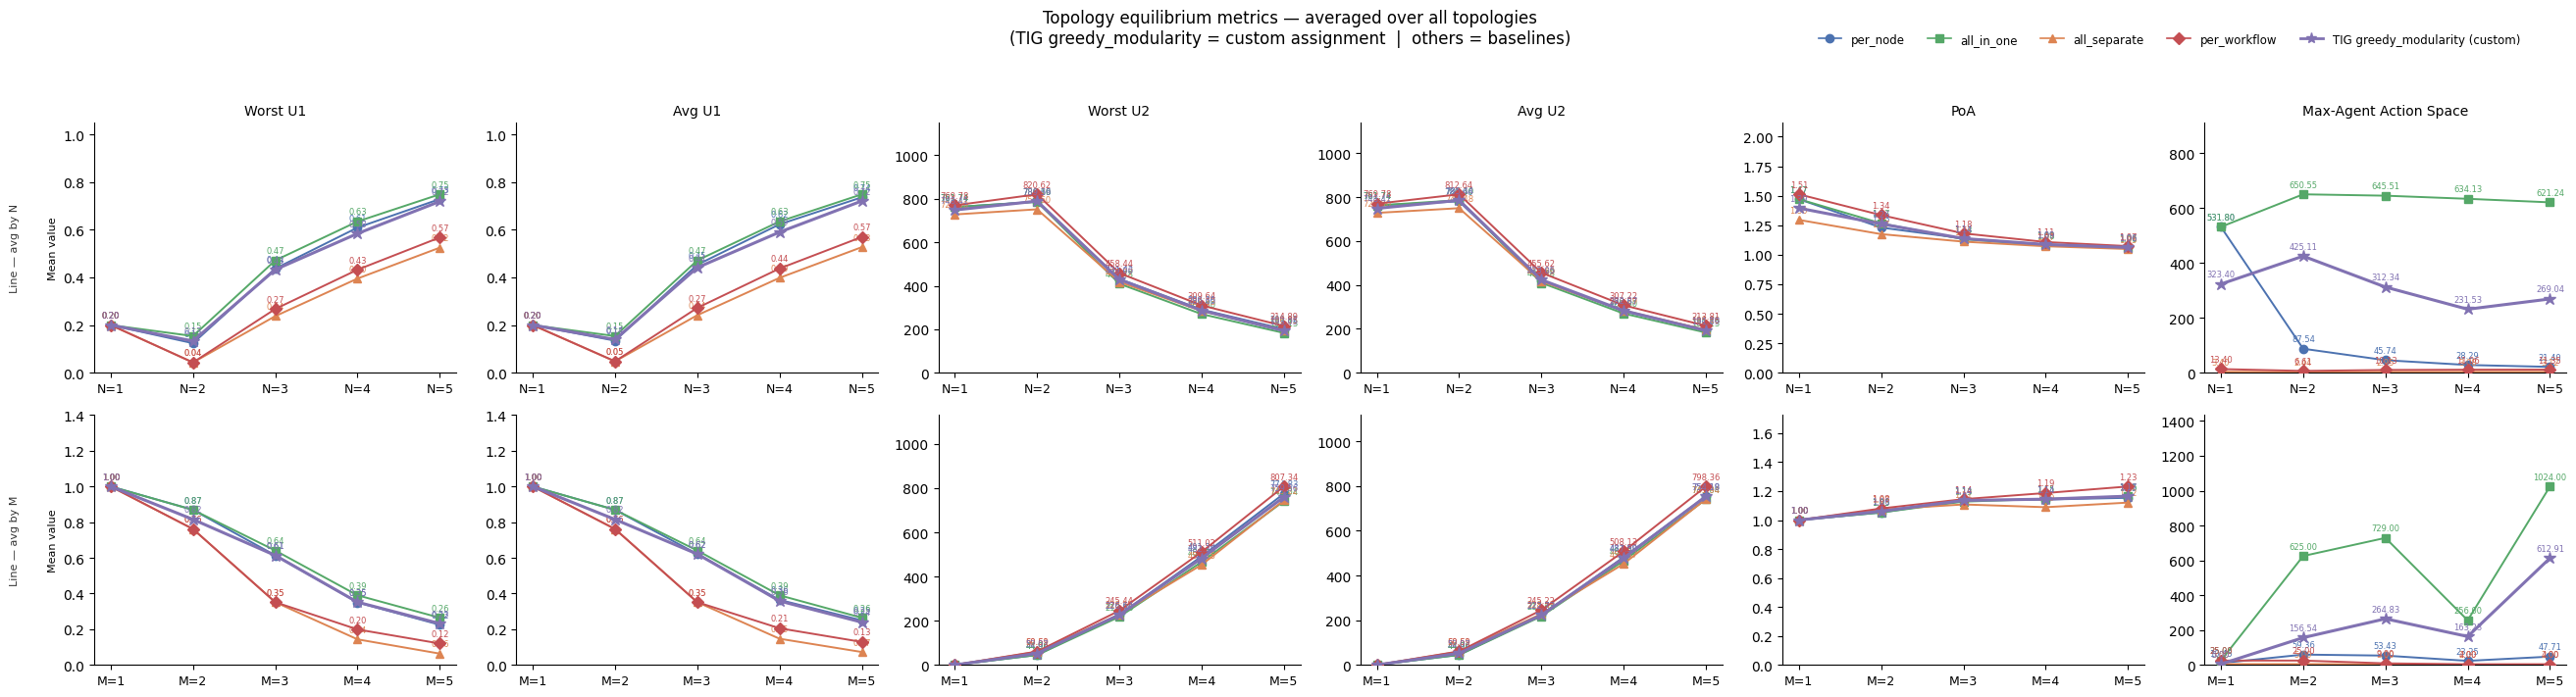

Saved → topology_equilibriums_plots.pdf


In [9]:
def bar_subplot(ax, group_data, group_vals, metric, group_label=None, title=None, show_ylabel=False):
    n_algos  = len(ALGOS)
    n_groups = len(group_vals)
    width    = 0.15
    offsets  = np.linspace(-(n_algos - 1) / 2, (n_algos - 1) / 2, n_algos) * width

    all_vals = [group_data[g][a][metric]
                for g in group_vals for a in ALGOS
                if metric in group_data[g].get(a, {})]
    ymax = max(all_vals) if all_vals and max(all_vals) > 0 else 1.0

    for ai, algo in enumerate(ALGOS):
        heights = [group_data[g].get(algo, {}).get(metric, 0) for g in group_vals]
        xs = np.arange(n_groups) + offsets[ai]
        lw    = 1.5 if algo == "tig_greedy_modularity" else 0.6
        hatch = "**" if algo == "tig_greedy_modularity" else None
        ax.bar(xs, heights, width=width,
               color=ALGO_COLORS[algo], edgecolor="white",
               hatch=hatch, linewidth=lw, label=ALGO_LABELS[algo])
        for x, h in zip(xs, heights):
            if h > 0:
                ax.text(x, h + ymax * 0.02, f"{h:.2f}",
                        ha="center", va="bottom", fontsize=5.5, rotation=45)

    ax.set_xticks(np.arange(n_groups))
    tick_labels = ([f"{group_label}={g}" for g in group_vals] if group_label
                   else [str(g) for g in group_vals])
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylim(0, ymax * 1.50)
    ax.spines[["top", "right"]].set_visible(False)
    if title:
        ax.set_title(title, fontsize=10)
    if show_ylabel:
        ax.set_ylabel("Mean value", fontsize=8)


def line_subplot(ax, group_data, group_vals, metric, group_label=None, title=None, show_ylabel=False):
    xs = list(range(len(group_vals)))
    all_vals = [group_data[g][a][metric]
                for g in group_vals for a in ALGOS
                if metric in group_data[g].get(a, {})]
    ymax = max(all_vals) if all_vals and max(all_vals) > 0 else 1.0

    for algo in ALGOS:
        ys = [group_data[g].get(algo, {}).get(metric, np.nan) for g in group_vals]
        lw = 2.2 if algo == "tig_greedy_modularity" else 1.4
        zorder = 5 if algo == "tig_greedy_modularity" else 3
        ms = 9 if algo == "tig_greedy_modularity" else 6
        ax.plot(xs, ys,
                color=ALGO_COLORS[algo],
                marker=ALGO_MARKERS[algo],
                linewidth=lw, markersize=ms,
                zorder=zorder, label=ALGO_LABELS[algo])
        for x, y in zip(xs, ys):
            if not np.isnan(y) and y > 0:
                ax.text(x, y + ymax * 0.03, f"{y:.2f}",
                        ha="center", va="bottom", fontsize=6, color=ALGO_COLORS[algo])

    ax.set_xticks(xs)
    tick_labels = ([f"{group_label}={g}" for g in group_vals] if group_label
                   else [str(g) for g in group_vals])
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylim(0, ymax * 1.40)
    ax.spines[["top", "right"]].set_visible(False)
    if title:
        ax.set_title(title, fontsize=10)
    if show_ylabel:
        ax.set_ylabel("Mean value", fontsize=8)


# ── Figure: 2 rows × len(METRICS) cols ───────────────────────────────────────
n_cols = len(METRICS)
fig, axes = plt.subplots(2, n_cols, figsize=(4.4 * n_cols, 7))
fig.suptitle(
    "Topology equilibrium metrics — averaged over all topologies\n"
    "(TIG greedy_modularity = custom assignment  |  others = baselines)",
    fontsize=12, y=1.01,
)

ROW_LABELS = ["Line — avg by N", "Line — avg by M"]

for col, metric in enumerate(METRICS):
    line_subplot(axes[0, col], by_N, sorted(by_N.keys()), metric, "N",
                 title=METRIC_LABELS[metric], show_ylabel=(col == 0))
    line_subplot(axes[1, col], by_M, sorted(by_M.keys()), metric, "M",
                 show_ylabel=(col == 0))

for row, label in enumerate(ROW_LABELS):
    axes[row, 0].annotate(
        label, xy=(0, 0.5), xycoords="axes fraction",
        xytext=(-62, 0), textcoords="offset points",
        fontsize=8, rotation=90, va="center", color="#333",
    )

handles = [
    plt.Line2D([0], [0],
               color=ALGO_COLORS[a],
               marker=ALGO_MARKERS[a],
               linewidth=2 if a == "tig_greedy_modularity" else 1.2,
               markersize=8 if a == "tig_greedy_modularity" else 6,
               label=ALGO_LABELS[a])
    for a in ALGOS
]
fig.legend(handles=handles, loc="upper left", ncol=5,
           bbox_to_anchor=(0.7, 0.99), fontsize=8.5, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
out = Path("topology_equilibriums_plots.pdf")
plt.savefig(out, bbox_inches="tight", format="pdf")
plt.show()
print(f"Saved → {out}")

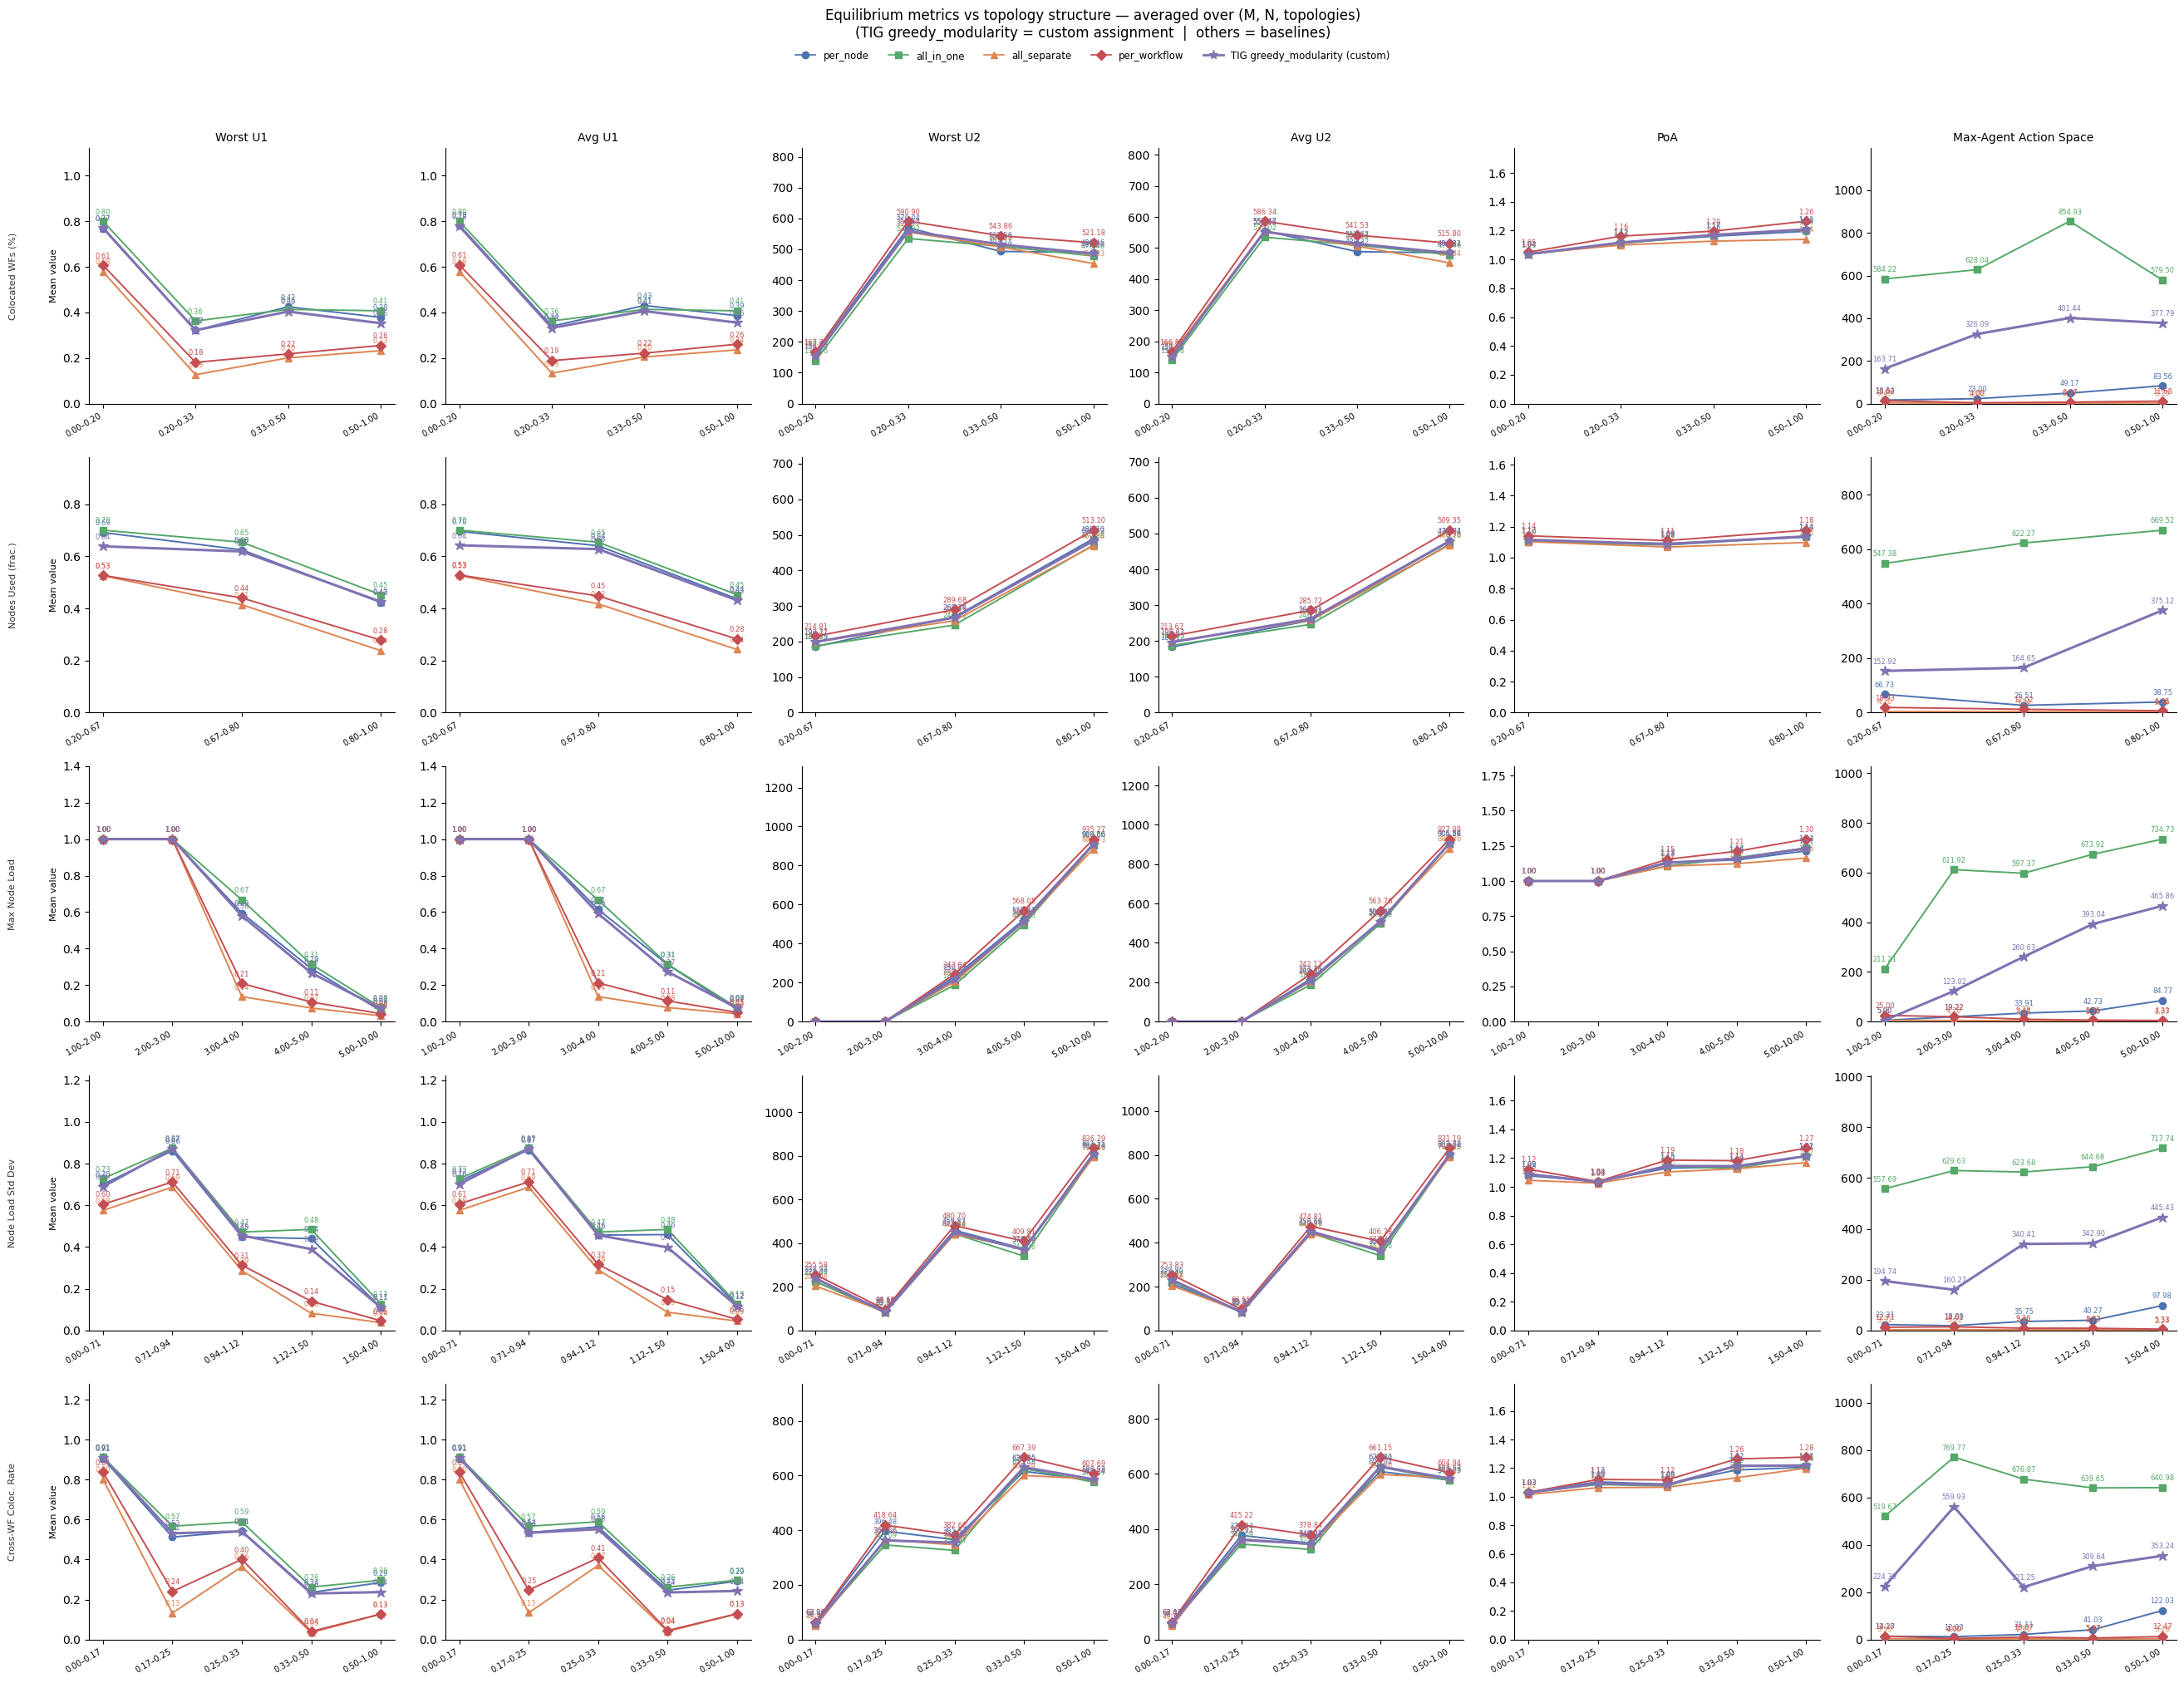

Saved → topology_metrics_plots.pdf


In [10]:
# ── Topology metric definitions ───────────────────────────────────────────────
TOPO_METRICS = [
    "t_pct_colocated",
    "t_frac_nodes_used",
    "t_max_node_load",
    "t_load_std",
    "t_cross_wf_coloc",
]
TOPO_LABELS = {
    "t_pct_colocated":   "Colocated WFs (%)",
    "t_frac_nodes_used": "Nodes Used (frac.)",
    "t_max_node_load":   "Max Node Load",
    "t_load_std":        "Node Load Std Dev",
    "t_cross_wf_coloc":  "Cross-WF Coloc. Rate",
}


def make_bins(records, metric, n_bins=5):
    """Bin a continuous metric into n_bins equal-frequency buckets.
    Returns the ordered list of bin label strings and annotates each record
    with record[f'{metric}_bin'].
    """
    vals = np.array([r[metric] for r in records])
    boundaries = np.unique(np.round(np.percentile(vals, np.linspace(0, 100, n_bins + 1)), 4))
    labels = [f"{boundaries[i]:.2f}–{boundaries[i + 1]:.2f}" for i in range(len(boundaries) - 1)]
    for r in records:
        idx = int(np.searchsorted(boundaries[1:-1], r[metric], side="right"))
        r[f"{metric}_bin"] = labels[idx]
    return labels  # already in ascending order


topo_bin_orders = {tm: make_bins(records, tm) for tm in TOPO_METRICS}
by_topo = {tm: grouped_means(records, f"{tm}_bin") for tm in TOPO_METRICS}

# ── Figure: 5 rows (topo metrics) × len(METRICS) cols (perf metrics) ─────────
n_rows = len(TOPO_METRICS)
n_cols = len(METRICS)
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 4 * n_rows))
fig2.suptitle(
    "Equilibrium metrics vs topology structure — averaged over (M, N, topologies)\n"
    "(TIG greedy_modularity = custom assignment  |  others = baselines)",
    fontsize=12, y=1.01,
)

for row, tm in enumerate(TOPO_METRICS):
    gd    = by_topo[tm]
    gvals = topo_bin_orders[tm]
    for col, metric in enumerate(METRICS):
        ax = axes2[row, col]
        line_subplot(ax, gd, gvals, metric, group_label=None,
                     title=(METRIC_LABELS[metric] if row == 0 else None),
                     show_ylabel=(col == 0))
        ax.set_xticklabels(gvals, fontsize=7, rotation=30, ha="right")
    axes2[row, 0].annotate(
        TOPO_LABELS[tm], xy=(0, 0.5), xycoords="axes fraction",
        xytext=(-70, 0), textcoords="offset points",
        fontsize=8, rotation=90, va="center", color="#333",
    )

handles2 = [
    plt.Line2D([0], [0],
               color=ALGO_COLORS[a], marker=ALGO_MARKERS[a],
               linewidth=2 if a == "tig_greedy_modularity" else 1.2,
               markersize=8 if a == "tig_greedy_modularity" else 6,
               label=ALGO_LABELS[a])
    for a in ALGOS
]
fig2.legend(handles=handles2, loc="upper center", ncol=5,
            bbox_to_anchor=(0.5, 0.99), fontsize=8.5, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
out2 = Path("topology_metrics_plots.pdf")
plt.savefig(out2, bbox_inches="tight", format="pdf")
plt.show()
print(f"Saved → {out2}")